In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels sqlalchemy pymysql joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import joblib

import warnings
warnings.filterwarnings("ignore")

## LOAD DATASET

In [3]:
df = pd.read_csv(r"C:\Users\pk706\Downloads\retail_demand_forecasting_3_years.csv")

In [4]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-01,store_1,item_10,18,20.59,0,1,1
2,2019-01-01,store_1,item_11,27,65.25,0,1,1
3,2019-01-01,store_1,item_12,13,60.88,0,1,1
4,2019-01-01,store_1,item_13,41,68.19,0,1,1


In [5]:
df.shape

(2740000, 8)

In [6]:
df.columns.tolist()

['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month']

## CREATE A SMALLER WORKING DATASET

### Select 10 stores and 10 items

In [7]:
selected_stores = df['store_id'].unique()[:10]
selected_items = df['item_id'].unique()[:10]

In [8]:
project_df = df[
    (df['store_id'].isin(selected_stores)) &
    (df['item_id'].isin(selected_items))
].copy()

In [9]:
project_df.shape

(109600, 8)

In [10]:
project_df.to_csv(
    "project_demand_data.csv",
    index=False
)

## load smaller subset dataset

In [3]:
df = pd.read_csv("project_demand_data.csv")

In [4]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-01,store_1,item_10,18,20.59,0,1,1
2,2019-01-01,store_1,item_11,27,65.25,0,1,1
3,2019-01-01,store_1,item_12,13,60.88,0,1,1
4,2019-01-01,store_1,item_13,41,68.19,0,1,1


In [5]:
df.shape

(109600, 8)

## BASIC DATA UNDERSTANDING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      109600 non-null  object 
 1   store_id  109600 non-null  object 
 2   item_id   109600 non-null  object 
 3   sales     109600 non-null  int64  
 4   price     109600 non-null  float64
 5   promo     109600 non-null  int64  
 6   weekday   109600 non-null  int64  
 7   month     109600 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 6.7+ MB


In [7]:
df.describe()

,sales,price,promo,weekday,month
count,109600.000000,109600.00000,109600.000000,109600.000000,109600.000000
mean,27.476651,51.21284,0.101332,2.998175,6.521898
std,13.160688,24.21429,0.301769,1.997726,3.449002
min,0.000000,8.14000,0.000000,0.000000,1.000000
25%,18.000000,30.39000,0.000000,1.000000,4.000000
50%,25.000000,49.06000,0.000000,3.000000,7.000000
75%,34.000000,68.34000,0.000000,5.000000,10.000000
max,115.000000,99.40000,1.000000,6.000000,12.000000


In [8]:
print('stores:', df['store_id'].nunique())

stores: 10


In [9]:
print('items:', df['item_id'].nunique())

items: 10


In [10]:
print('start date:', df['date'].min())
print('end date:', df['date'].max())

start date: 2019-01-01
end date: 2021-12-31


## DATA CLEANING

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(
    df.duplicated(
        subset=['date', 'store_id', 'item_id']
    ).sum()
)

0


In [15]:
df.drop_duplicates().reset_index(drop=True)

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-01,store_1,item_10,18,20.59,0,1,1
2,2019-01-01,store_1,item_11,27,65.25,0,1,1
3,2019-01-01,store_1,item_12,13,60.88,0,1,1
4,2019-01-01,store_1,item_13,41,68.19,0,1,1
...,...,...,...,...,...,...,...,...
109595,2021-12-31,store_18,item_14,32,32.92,1,4,12
109596,2021-12-31,store_18,item_15,17,68.04,0,4,12
109597,2021-12-31,store_18,item_16,30,28.80,0,4,12
109598,2021-12-31,store_18,item_17,21,97.93,0,4,12


In [16]:
df = df.sort_values(
    ['store_id', 'item_id', 'date']
).reset_index(drop=True)

## SALES DISTRIBUTION

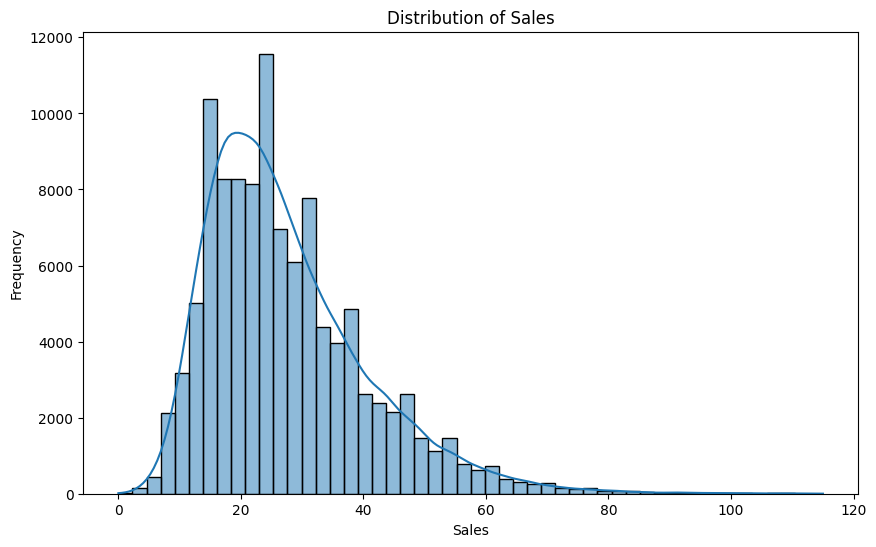

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## BOXPLOT

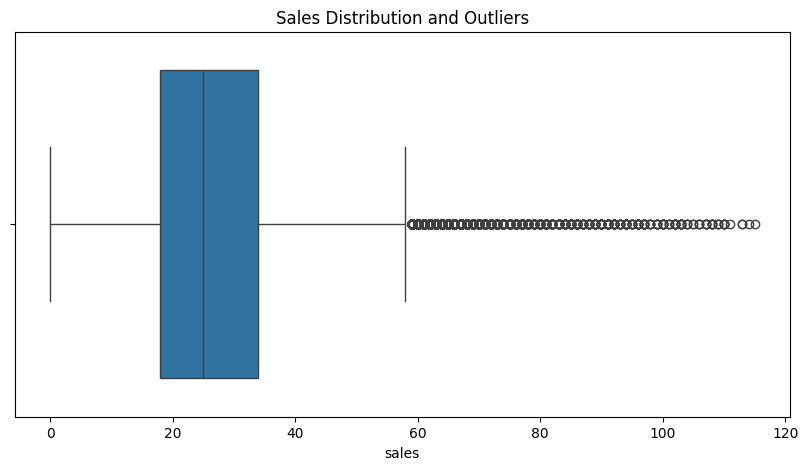

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["sales"]
)

plt.title("Sales Distribution and Outliers")

plt.show()

## IQR OUTLIER ANALYSIS

In [19]:
Q1 = df['sales'].quantile(0.25)

Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

### find outliers

In [20]:
outliers = df[
    (df['sales'] < lower_bound) |
    (df['sales'] > upper_bound)
    ]     

In [21]:
print('number of outliers:', len(outliers))

number of outliers: 3122


## OVERALL DAILY SALES TREND

In [22]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
    .reset_index()
)

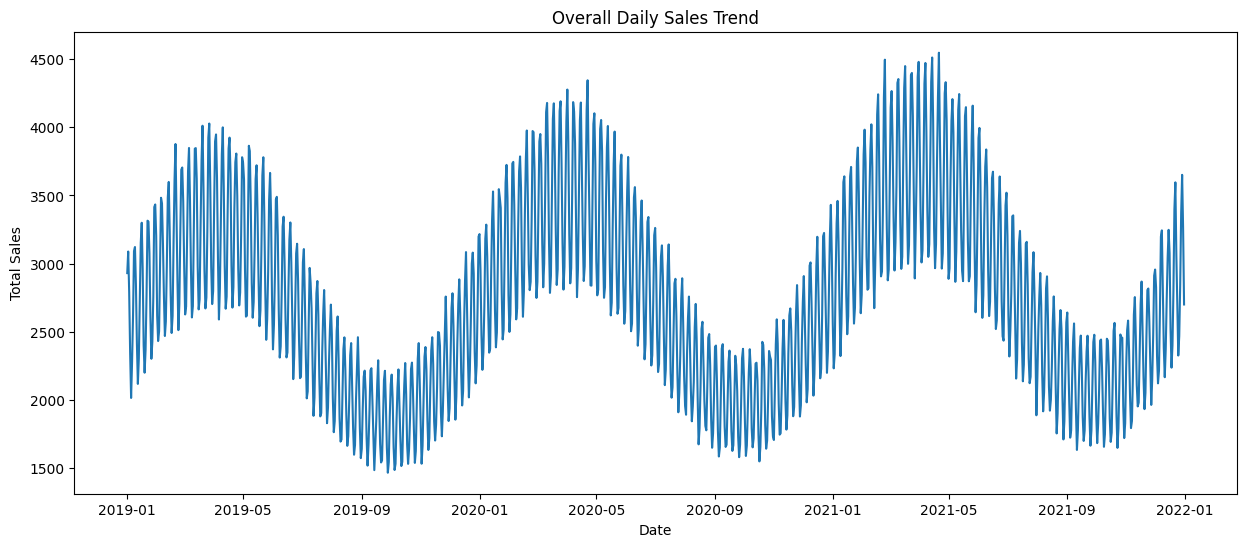

In [23]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

## MONTHLY SALES TREND

In [24]:
monthly_sales = (
    df.set_index("date")["sales"]
    .resample("ME")
    .sum()
)

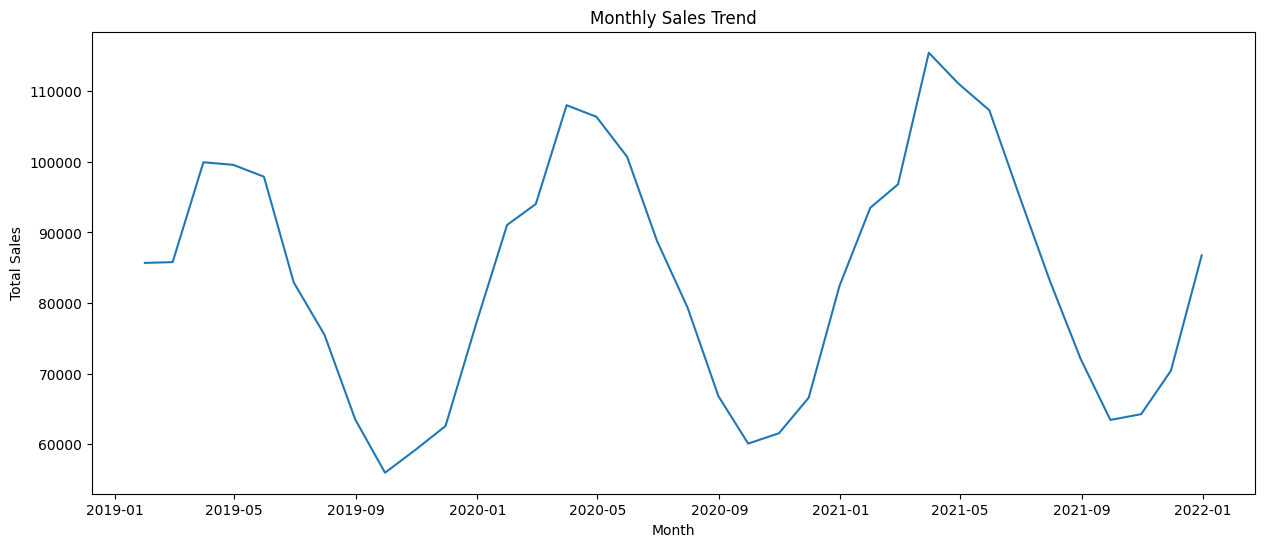

In [25]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

## SALES BY STORE

In [26]:
store_sales = (
    df.groupby("store_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
store_12    367252
store_13    350384
store_10    336594
store_18    313082
store_1     293558
store_17    285688
store_14    274071
store_16    270814
store_15    270229
store_11    249769
Name: sales, dtype: int64

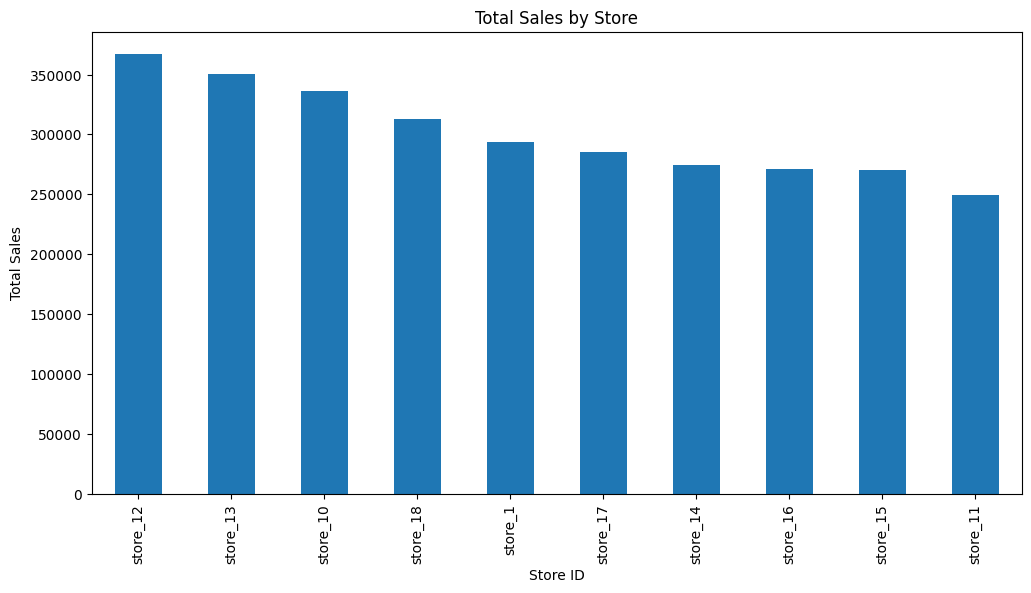

In [27]:
plt.figure(figsize=(12, 6))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")

plt.show()

## SALES BY ITEM

In [28]:
item_sales = (
    df.groupby("item_id")["sales"]
    .sum()
    .sort_values(ascending=False)
)

item_sales.head(10)

item_id
item_1     475679
item_13    424635
item_18    415398
item_16    320426
item_11    263437
item_14    252121
item_10    240936
item_15    225533
item_12    220493
item_17    172783
Name: sales, dtype: int64

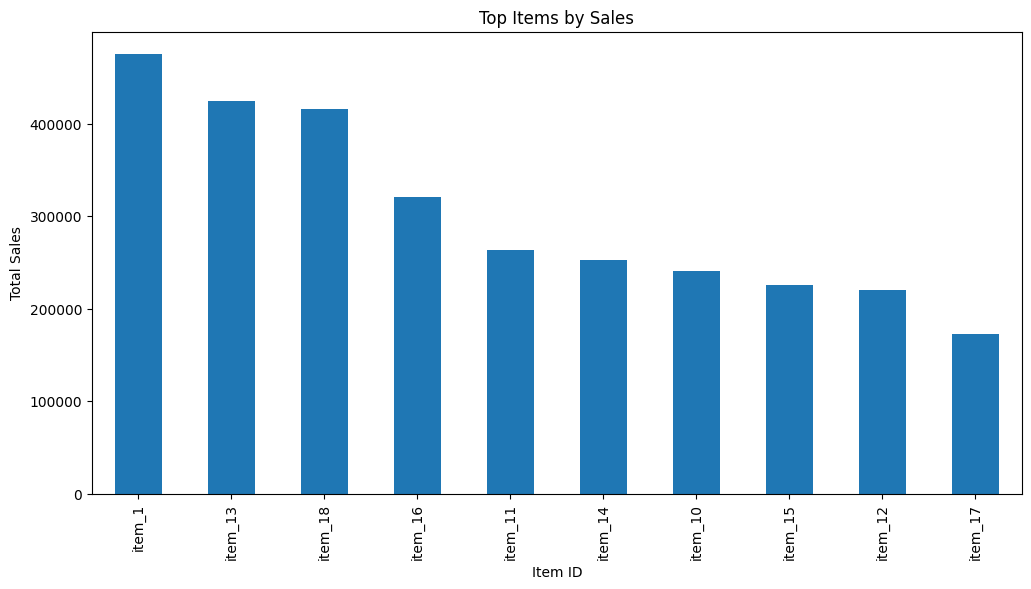

In [29]:
plt.figure(figsize=(12, 6))

item_sales.head(10).plot(kind="bar")

plt.title("Top Items by Sales")
plt.xlabel("Item ID")
plt.ylabel("Total Sales")

plt.show()

## PROMOTION ANALYSIS

In [30]:
promo_sales = (
    df.groupby("promo")["sales"]
    .mean()
)

promo_sales

promo
0    26.145593
1    39.281199
Name: sales, dtype: float64

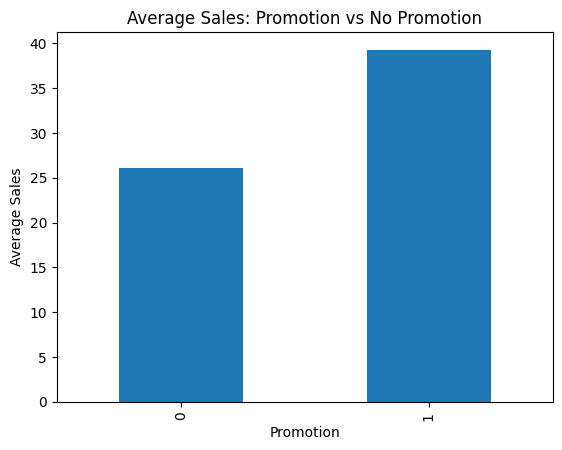

In [31]:
promo_sales.plot(kind="bar")

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

## WEEKDAY ANALYSIS

In [32]:
weekday_sales = (
    df.groupby("weekday")["sales"]
    .mean()
)

weekday_sales

weekday
0    27.447692
1    31.811019
2    32.836051
3    29.821529
4    25.042994
5    22.129359
6    23.186346
Name: sales, dtype: float64

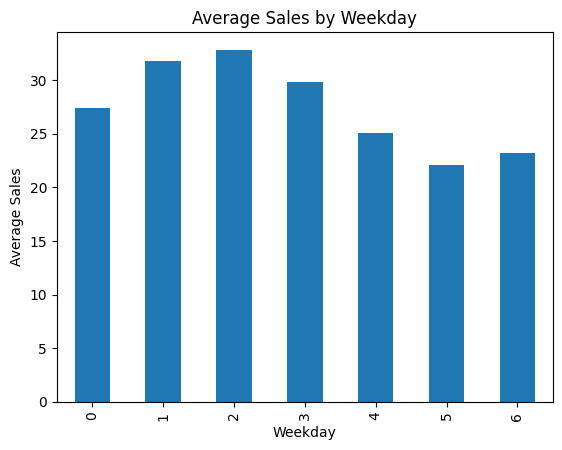

In [33]:
weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Sales")

plt.show()

## MONTHLY SEASONALITY ANALYSIS

In [34]:
month_sales = (
    df.groupby("month")["sales"]
    .mean()
)

month_sales

month
1     29.058387
2     32.548588
3     34.774839
4     35.224333
5     32.894301
6     29.674111
7     25.591720
8     21.769677
9     19.950778
10    19.904086
11    22.184222
12    26.488387
Name: sales, dtype: float64

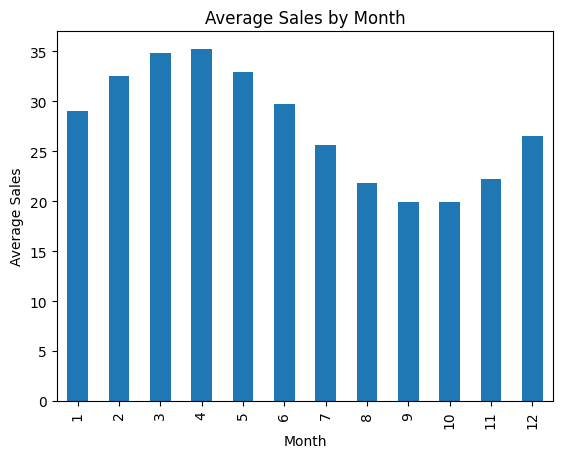

In [35]:

month_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

## FEATURE ENGINEERING

In [36]:
df["year"] = df["date"].dt.year

df["day"] = df["date"].dt.day

df["day_of_year"] = df["date"].dt.dayofyear

df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df["quarter"] = df["date"].dt.quarter

### Weekend feature:

In [37]:
df["is_weekend"] = (
    df["weekday"] >= 5
).astype(int)

### create lag features:

#### lag 1:

In [38]:
df["lag_1"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .shift(1)
)

#### lag 7:

In [39]:
df["lag_7"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .shift(7)
)

#### lag 14:

In [40]:
df["lag_14"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .shift(14)
)

#### lag 30:

In [41]:
df["lag_30"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .shift(30)
)

### Rolling mean features

#### 7 day rolling mean:

In [42]:
df["rolling_mean_7"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

#### 14 day rolling mean:

In [43]:
df["rolling_mean_14"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

#### 30 day rolling mean:

In [45]:
df["rolling_mean_30"] = (
    df.groupby(
        ["store_id", "item_id"]
    )["sales"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

## remove missing values created by lags

In [46]:
df = df.dropna().reset_index(drop=True)

In [47]:
df.isnull().sum()

date               0
store_id           0
item_id            0
sales              0
price              0
promo              0
weekday            0
month              0
year               0
day                0
day_of_year        0
week_of_year       0
quarter            0
is_weekend         0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
dtype: int64

## PYTHON SQL SERVER CONNECTION

In [48]:
from sqlalchemy import create_engine

server = r'localhost\SQLEXPRESS'
database = 'demand_forecasting'

connection_string = (
    f"mssql+pyodbc://{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)
con = engine.connect()

## TEST SQL CONNECTION

In [49]:
with engine.connect() as connection:
    print("SQL Server connection successful!")

SQL Server connection successful!


## SEND PANDAS DATA TO SQL SERVER

In [50]:
df.to_sql(
    "retail_sales",
    con=engine,
    if_exists="replace",
    index=False
)

76

## VERIFY SQL DATA FROM JUPYTER

In [51]:
query = """
SELECT TOP 10 *
FROM retail_sales
"""

sql_data = pd.read_sql(
    query,
    engine
)

sql_data

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,...,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30
0,2019-01-31,store_1,item_1,50,21.30,0,3,1,2019,31,...,5,1,0,57.0,40.0,46.0,41.0,42.714286,42.142857,42.766667
1,2019-02-01,store_1,item_1,41,21.30,0,4,2,2019,1,...,5,1,0,50.0,38.0,40.0,53.0,44.142857,42.428571,43.066667
2,2019-02-02,store_1,item_1,34,21.30,0,5,2,2019,2,...,5,1,1,41.0,34.0,33.0,39.0,44.571429,42.500000,42.666667
3,2019-02-03,store_1,item_1,34,21.30,0,6,2,2019,3,...,5,1,1,34.0,40.0,39.0,35.0,44.571429,42.571429,42.500000
4,2019-02-04,store_1,item_1,64,17.04,1,0,2,2019,4,...,6,1,0,34.0,44.0,38.0,51.0,43.714286,42.214286,42.466667
5,2019-02-05,store_1,item_1,54,21.30,0,1,2,2019,5,...,6,1,0,64.0,46.0,47.0,38.0,46.571429,44.071429,42.900000
6,2019-02-06,store_1,item_1,58,21.30,0,2,2,2019,6,...,6,1,0,54.0,57.0,48.0,45.0,47.714286,44.571429,43.433333
7,2019-02-07,store_1,item_1,53,21.30,0,3,2,2019,7,...,6,1,0,58.0,50.0,40.0,48.0,47.857143,45.285714,43.866667
8,2019-02-08,store_1,item_1,39,21.30,0,4,2,2019,8,...,6,1,0,53.0,41.0,38.0,50.0,48.285714,46.214286,44.033333
9,2019-02-09,store_1,item_1,50,17.04,1,5,2,2019,9,...,6,1,1,39.0,34.0,34.0,44.0,48.000000,46.285714,43.666667


### total sales:

In [52]:
result = pd.read_sql("""
SELECT SUM(sales) AS Total_Sales
FROM retail_sales
""", con)

result

,Total_Sales
0,2928951


In [53]:
result = pd.read_sql("""
SELECT AVG(sales) AS Average_Sales
FROM retail_sales
""", con)

result

,Average_Sales
0,27


### sales by store:

In [54]:
result = pd.read_sql("""
SELECT
    store_id,
    SUM(sales) AS Total_Sales
FROM retail_sales
GROUP BY store_id
ORDER BY Total_Sales DESC
""", con)

result

,store_id,Total_Sales
0,store_12,357122
1,store_13,340990
2,store_10,327270
3,store_18,304544
4,store_1,285504
5,store_17,277936
6,store_14,266572
7,store_16,263389
8,store_15,262744
9,store_11,242880


### sales by item:

In [55]:
result = pd.read_sql("""
SELECT
    item_id,
    SUM(sales) AS Total_Sales
FROM retail_sales
GROUP BY item_id
ORDER BY Total_Sales DESC
""", con)

result

,item_id,Total_Sales
0,item_1,462576
1,item_13,412939
2,item_18,404086
3,item_16,311657
4,item_11,256323
5,item_14,245275
6,item_10,234284
7,item_15,219332
8,item_12,214429
9,item_17,168050


### Promotion impact:

In [56]:
result = pd.read_sql("""
SELECT
    promo,
    AVG(sales) AS Average_Sales,
    SUM(sales) AS Total_Sales
FROM retail_sales
GROUP BY promo
""", con)

result

,promo,Average_Sales,Total_Sales
0,0,26,2504085
1,1,39,424866


### monthly sales:

In [57]:
result = pd.read_sql("""
SELECT
    YEAR(date) AS Year,
    MONTH(date) AS Month,
    SUM(sales) AS Total_Sales
FROM retail_sales
GROUP BY
    YEAR(date),
    MONTH(date)
ORDER BY
    Year,
    Month
""", con)

result

,Year,Month,Total_Sales
0,2019,1,3204
1,2019,2,85802
2,2019,3,99940
3,2019,4,99579
4,2019,5,97900
5,2019,6,82936
6,2019,7,75514
7,2019,8,63532
8,2019,9,55987
9,2019,10,59258


### TOP 5 STORES:

In [58]:
result = pd.read_sql("""
SELECT TOP 5
    store_id,
    SUM(sales) AS Total_Sales
FROM retail_sales
GROUP BY store_id
ORDER BY Total_Sales DESC
""", con)

result

,store_id,Total_Sales
0,store_12,357122
1,store_13,340990
2,store_10,327270
3,store_18,304544
4,store_1,285504


## PREPARE ML FEATURES

In [59]:
target = 'sales'

In [60]:
features = [
    "store_id",
    "item_id",
    "price",
    "promo",
    "weekday",
    "month",
    "year",
    "day",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

## TIME-BASED TRAIN/TEST SPLIT

### sort by date:

In [73]:
df = df.sort_values("date").reset_index(drop=True)

### find the 80% date:

In [74]:
split_date = df["date"].quantile(0.80)

print(split_date)

2021-06-01 00:00:00


### create train and test datasets:

In [75]:
train = df[
    df["date"] <= split_date
].copy()

test = df[
    df["date"] > split_date
].copy()

### create X and Y:

In [76]:
X_train = train[features]

y_train = train[target]

X_test = test[features]

y_test = test[target]

In [77]:
print(X_train.shape)
print(X_test.shape)

(85300, 19)
(21300, 19)


## RANDOM FOREST

In [78]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [79]:
from sklearn.preprocessing import LabelEncoder

In [80]:
store_encoder = LabelEncoder()

df["store_id"] = store_encoder.fit_transform(df["store_id"])

In [81]:
item_encoder = LabelEncoder()

df["item_id"] = item_encoder.fit_transform(df["item_id"])

In [82]:
df[["store_id", "item_id"]].head()

,store_id,item_id
0,0,0
1,2,1
2,2,7
3,2,6
4,2,8


### train:

In [83]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### predict:

In [89]:
rf_predictions = rf_model.predict(
    X_test
)

### evaluate:

In [90]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_mape = mean_absolute_percentage_error(
    y_test,
    rf_predictions
) * 100

In [91]:
print("RANDOM FOREST RESULTS")

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

print("MAPE:", rf_mape)

RANDOM FOREST RESULTS
MAE: 2.6702943905986527
RMSE: 3.364938814682806
MAPE: 521213060616621.2


## XGBOOST

In [92]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

### Train:

In [93]:
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

### predict:

In [94]:
xgb_predictions = xgb_model.predict(
    X_test
)

### evaluate:

In [95]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
) * 100

In [96]:
print("XGBOOST RESULTS")

print("MAE:", xgb_mae)

print("RMSE:", xgb_rmse)

print("MAPE:", xgb_mape)

XGBOOST RESULTS
MAE: 2.570561170578003
RMSE: 3.2246663061392424
MAPE: 514938581811200.0


## ARIMA

### for ARIMA, aggregate sales by date

In [97]:
daily_demand = (
    df.groupby("date")["sales"]
    .sum()
    .sort_index()
)

### split:

In [98]:
split = int(
    len(daily_demand) * 0.80
)

arima_train = daily_demand.iloc[:split]

arima_test = daily_demand.iloc[split:]

### train:

In [99]:
arima_model = ARIMA(
    arima_train,
    order=(5, 1, 2)
)

arima_result = arima_model.fit()

### forecast:

In [100]:
arima_predictions = arima_result.forecast(
    steps=len(arima_test)
)

### evaluate:

In [101]:
arima_mae = mean_absolute_error(
    arima_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        arima_predictions
    )
)

arima_mape = mean_absolute_percentage_error(
    arima_test,
    arima_predictions
) * 100

### results:

In [102]:
print("ARIMA RESULTS")

print("MAE:", arima_mae)

print("RMSE:", arima_rmse)

print("MAPE:", arima_mape)

ARIMA RESULTS
MAE: 863.682231098977
RMSE: 943.8548493769123
MAPE: 38.24511345214433


## SARIMA

## create SARIMA model:

In [103]:
sarima_model = SARIMAX(
    arima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

### train:

In [104]:
sarima_result = sarima_model.fit(
    disp=False
)

### forecast:

In [105]:
sarima_predictions = sarima_result.forecast(
    steps=len(arima_test)
)

## evaluate:

In [106]:
sarima_mae = mean_absolute_error(
    arima_test,
    sarima_predictions
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        sarima_predictions
    )
)

sarima_mape = mean_absolute_percentage_error(
    arima_test,
    sarima_predictions
) * 100

In [107]:
print("SARIMA RESULTS")

print("MAE:", sarima_mae)

print("RMSE:", sarima_rmse)

print("MAPE:", sarima_mape)

SARIMA RESULTS
MAE: 418.1888216497586
RMSE: 575.0560991727325
MAPE: 16.707263830665692


## COMPARE ALL 4 MODELS

In [108]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "ARIMA",
        "SARIMA"
    ],
    
    "MAE": [
        rf_mae,
        xgb_mae,
        arima_mae,
        sarima_mae
    ],
    
    "RMSE": [
        rf_rmse,
        xgb_rmse,
        arima_rmse,
        sarima_rmse
    ],
    
    "MAPE": [
        rf_mape,
        xgb_mape,
        arima_mape,
        sarima_mape
    ]
})

In [109]:
final_results.sort_values(
    by="RMSE"
)

,Model,MAE,RMSE,MAPE
1,XGBoost,2.570561,3.224666,5.149386e+14
0,Random Forest,2.670294,3.364939,5.212131e+14
3,SARIMA,418.188822,575.056099,1.670726e+01
2,ARIMA,863.682231,943.854849,3.824511e+01


## FEATURE IMPORTANCE

### For random forest:

In [110]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

### sort:

In [111]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

### plot:

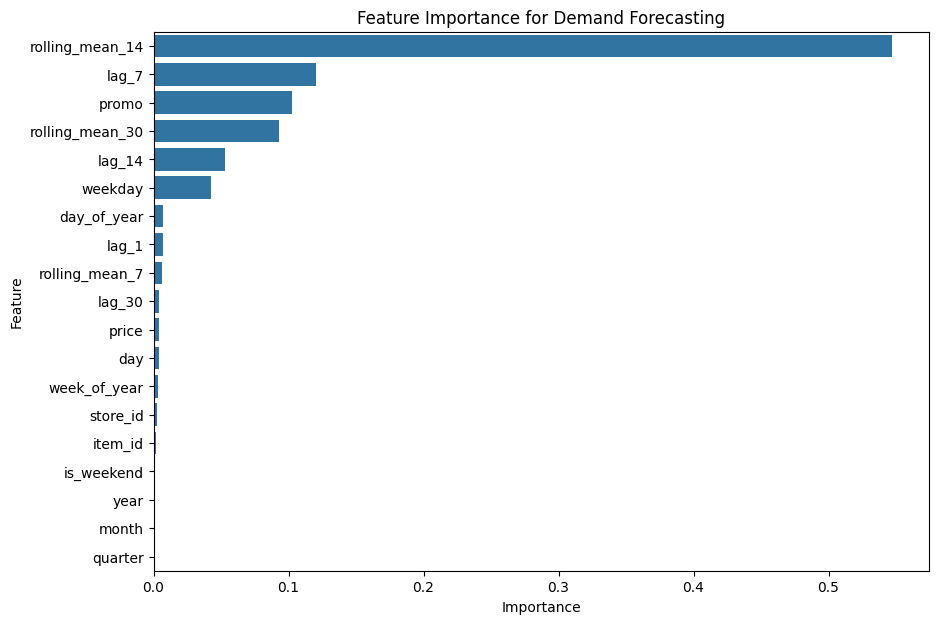

In [112]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Demand Forecasting")

plt.show()

## ACTUAL VS PREDICTED (XGBOOST)

### create comparison

In [113]:
comparison = test[
    ["date", "store_id", "item_id", "sales"]
].copy()

### add predictions

In [114]:
comparison["predicted_sales"] = xgb_predictions

### check

In [115]:
comparison.head()

,date,store_id,item_id,sales,predicted_sales
85300,2021-06-02,2,9,40,43.370056
85301,2021-06-02,5,2,44,44.827103
85302,2021-06-02,2,4,46,45.715195
85303,2021-06-02,3,8,23,25.915665
85304,2021-06-02,1,0,103,100.129570


### for visualization, aggregate by date:

In [116]:
daily_comparison = comparison.groupby("date").agg(
    actual_sales=("sales", "sum"),
    predicted_sales=("predicted_sales", "sum")
).reset_index()

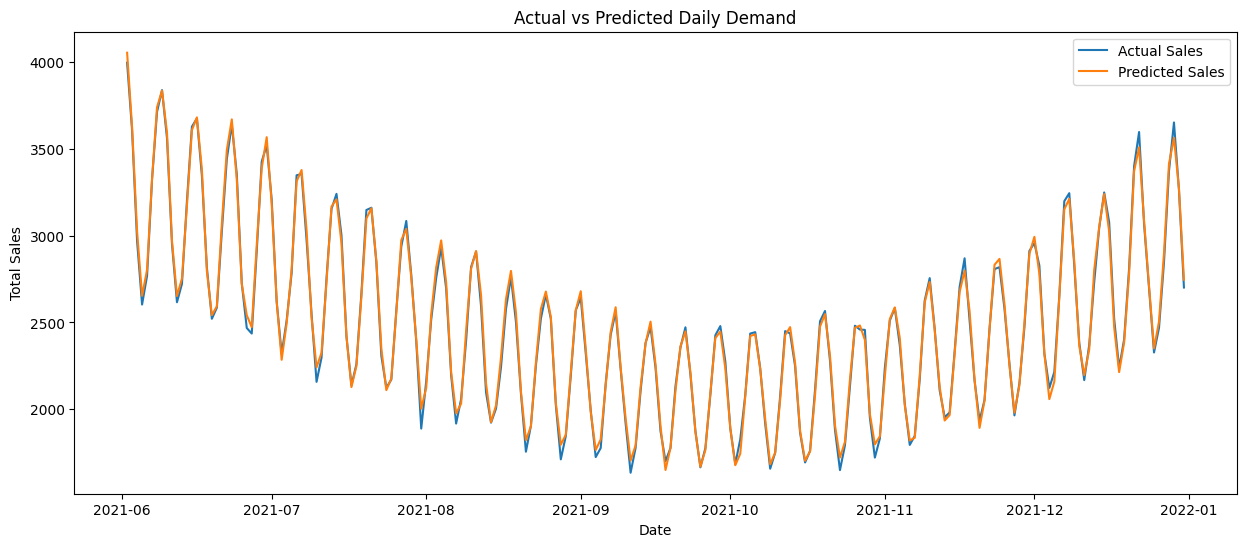

In [117]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_comparison["date"],
    daily_comparison["actual_sales"],
    label="Actual Sales"
)

plt.plot(
    daily_comparison["date"],
    daily_comparison["predicted_sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Daily Demand")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.legend()

plt.show()

## COMPARE ARIMA AND SARIMA VISUALLY

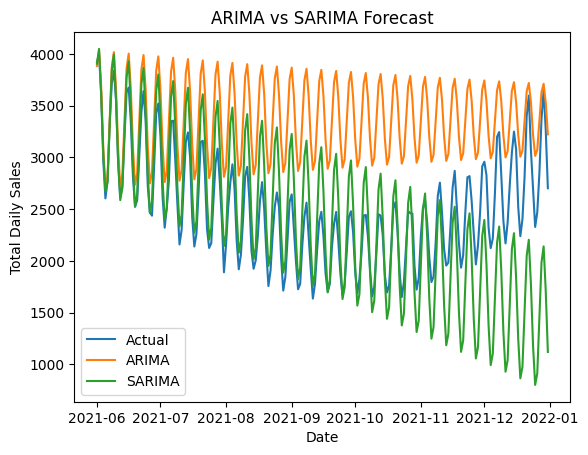

In [118]:
plt.plot(
    arima_test.index,
    arima_test.values,
    label="Actual"
)

plt.plot(
    arima_test.index,
    arima_predictions,
    label="ARIMA"
)

plt.plot(
    arima_test.index,
    sarima_predictions,
    label="SARIMA"
)

plt.title("ARIMA vs SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Total Daily Sales")

plt.legend()

plt.show()

## SAVE THE BEST ML MODEL

In [119]:
joblib.dump(
    xgb_model,
    "demand_forecasting_model.pkl"
)

['demand_forecasting_model.pkl']

In [120]:
model = joblib.load(
    "demand_forecasting_model.pkl"
)

## EXPORT RESULTS FOR POWER BI

### export predictions

In [121]:
comparison.to_csv(
    "forecast_results.csv",
    index=False
)

### export model results

In [122]:
final_results.to_csv(
    "model_comparison.csv",
    index=False
)

### export feature importance

In [123]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)